In [ ]:
# ── 0. Environment setup ──────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Libraries loaded")

✅ Libraries loaded


In [ ]:
# ── 1. Load data ──────────────────────────────────────────────────────
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Final Assignment/telecom/'

client = pd.read_csv(DATA_PATH + 'Client.csv')
record = pd.read_csv(DATA_PATH + 'Record.csv')

print(f"Client:  {client.shape[0]:,} rows × {client.shape[1]} cols")
print(f"Record:  {record.shape[0]:,} rows × {record.shape[1]} cols")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Client:  100,000 rows × 50 cols
Record:  100,000 rows × 51 cols


In [ ]:
# ── 2. Merge datasets ─────────────────────────────────────────────────
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged:  {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head(3)

Merged:  100,000 rows × 100 cols


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0


In [ ]:
# ── 3.data health check ────────────────────────────────────────
print("=== Missing values (top 15) ===")
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0].head(15).apply(lambda x: f"{x:.1%}"))

print("\n=== Key revenue columns ===")
print(df[['rev_Mean', 'ovrrev_Mean', 'avgrev', 'change_rev']].describe().round(2))

=== Missing values (top 15) ===
numbcars            49.4%
dwllsize            38.3%
HHstatin            37.9%
ownrent             33.7%
dwlltype            31.9%
lor                 30.2%
income              25.4%
adults              23.0%
infobase            22.1%
hnd_webcap          10.2%
prizm_social_one     7.4%
avg6mou              2.8%
avg6qty              2.8%
avg6rev              2.8%
truck                1.7%
dtype: object

=== Key revenue columns ===
       rev_Mean  ovrrev_Mean     avgrev  change_rev
count  99643.00     99643.00  100000.00    99109.00
mean      58.72        13.56      57.91       -1.02
std       46.29        30.50      36.16       50.36
min       -6.17         0.00       0.48    -1107.74
25%       33.26         0.00      35.37       -7.36
50%       48.20         1.00      49.89       -0.32
75%       70.75        14.44      69.48        1.64
max     3843.26      1102.40     924.27     9963.66


In [ ]:
# — 4. Target variable & column triage ------------------------------------
print(f"Churn rate: {df['churn'].mean():.1%}")

# Columns >30% missing
high_missing = ['numbcars', 'dwllsize', 'HHstatin', 'ownrent', 'dwlltype', 'lor']
df = df.drop(columns=high_missing)

cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df.columns if c not in cat_cols + ['churn', 'Customer_ID']]
print(f"{len(cat_cols)} categorical, {len(num_cols)} numeric columns kept")

Churn rate: 49.6%
17 categorical, 75 numeric columns kept


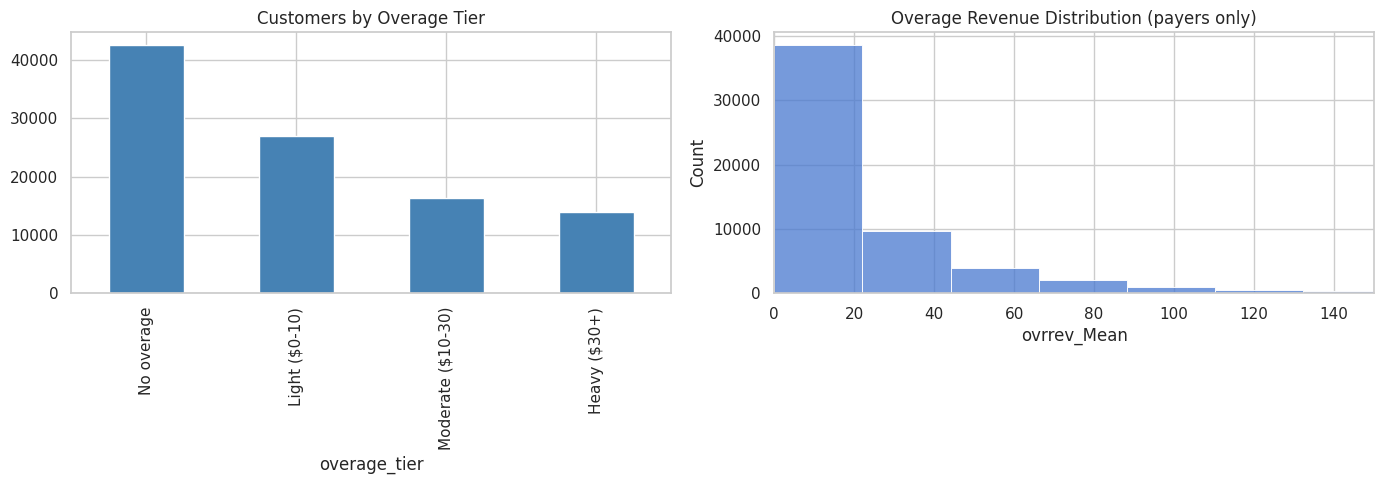

57.1% of customers pay overage
Among payers, average overage = $23.67/month


In [ ]:
# — 5. EDA: overage behaviour across the customer base ---------------------
df['overage_tier'] = pd.cut(df['ovrrev_Mean'], bins=[-0.01, 0, 10, 30, df['ovrrev_Mean'].max()],
                             labels=['No overage', 'Light ($0-10)', 'Moderate ($10-30)', 'Heavy ($30+)'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df['overage_tier'].value_counts().reindex(
    ['No overage', 'Light ($0-10)', 'Moderate ($10-30)', 'Heavy ($30+)']
).plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Customers by Overage Tier')

sns.histplot(df.loc[df['ovrrev_Mean'] > 0, 'ovrrev_Mean'], bins=50, ax=ax[1])
ax[1].set_xlim(0, 150)
ax[1].set_title('Overage Revenue Distribution (payers only)')
plt.tight_layout(); plt.show()

print(f"{(df['ovrrev_Mean']>0).mean():.1%} of customers pay overage")
print(f"Among payers, average overage = ${df.loc[df['ovrrev_Mean']>0,'ovrrev_Mean'].mean():.2f}/month")

overage_tier
No overage           0.490294
Light ($0-10)        0.480135
Moderate ($10-30)    0.504939
Heavy ($30+)         0.526190
Name: churn, dtype: float64


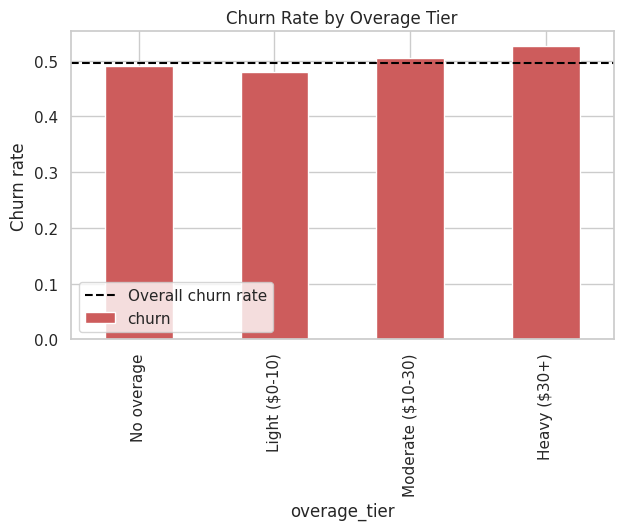

In [ ]:
# — 6. EDA: --------------------------
churn_by_tier = df.groupby('overage_tier', observed=True)['churn'].mean()
print(churn_by_tier)

churn_by_tier.plot(kind='bar', color='indianred', figsize=(7, 4))
plt.axhline(df['churn'].mean(), color='black', linestyle='--', label='Overall churn rate')
plt.ylabel('Churn rate'); plt.title('Churn Rate by Overage Tier'); plt.legend()
plt.show()

eqpdays          0.112691
hnd_price       -0.103184
totmrc_Mean     -0.068558
mou_Mean        -0.057027
mou_cvce_Mean   -0.052042
complete_Mean   -0.051740
comp_vce_Mean   -0.051574
avg3mou         -0.049546
mou_opkv_Mean   -0.048896
attempt_Mean    -0.048533
plcd_vce_Mean   -0.048321
peak_vce_Mean   -0.048320
opk_vce_Mean    -0.047873
mou_peav_Mean   -0.047287
mou_rvce_Mean   -0.047148
Name: churn, dtype: float64


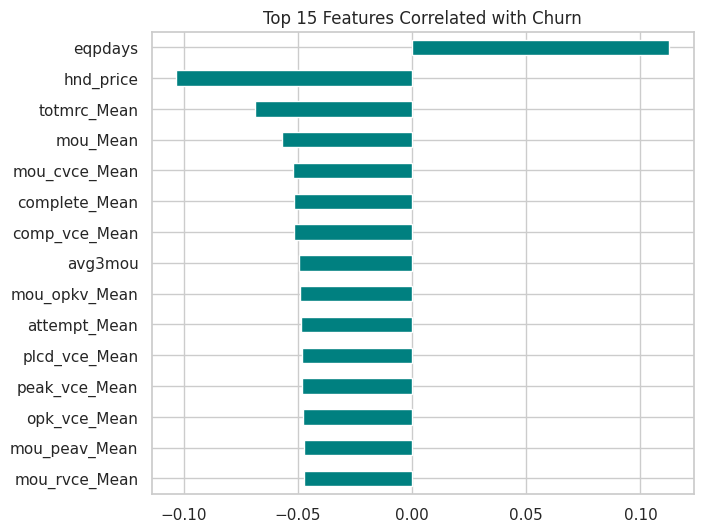

In [ ]:
# — 7. EDA: --------------------------------------
numeric_df = df.select_dtypes(include=['float64', 'int64'])
churn_corr = numeric_df.corr(numeric_only=True)['churn'].drop('churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(15))

churn_corr.head(15).plot(kind='barh', figsize=(7, 6), color='teal')
plt.gca().invert_yaxis(); plt.title('Top 15 Features Correlated with Churn'); plt.show()

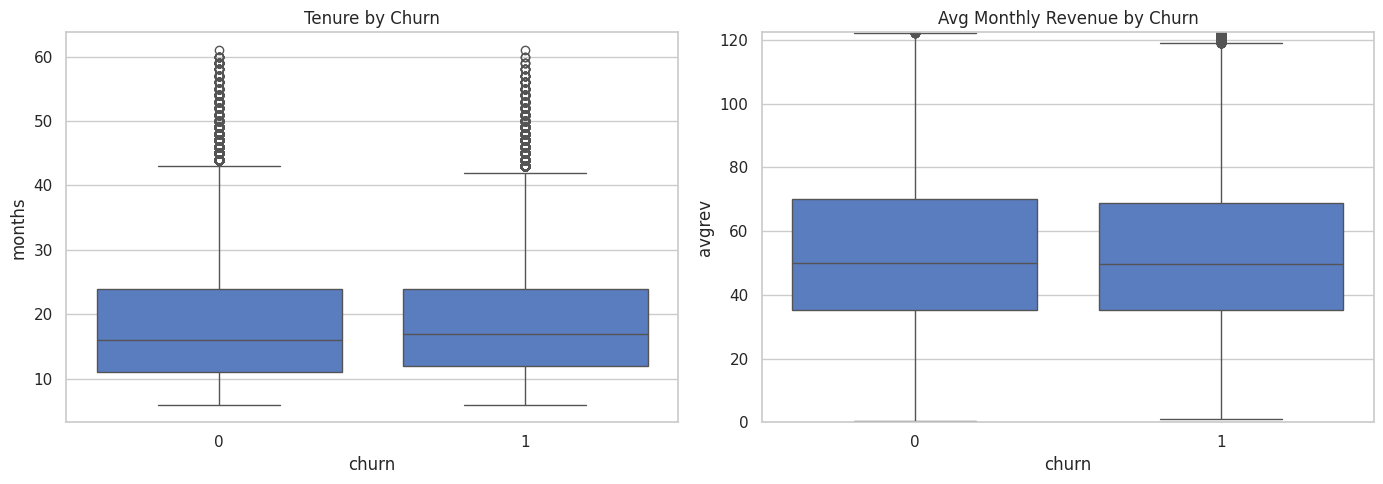

In [ ]:
# — 8. EDA: revenue & tenure patterns ------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='churn', y='months', ax=ax[0]); ax[0].set_title('Tenure by Churn')
sns.boxplot(data=df, x='churn', y='avgrev', ax=ax[1]); ax[1].set_ylim(0, df['avgrev'].quantile(0.95))
ax[1].set_title('Avg Monthly Revenue by Churn')
plt.tight_layout(); plt.show()

In [ ]:
# — 9. Feature engineering ------------------------------------------------------
fe = df.copy()
fe['overage_ratio']   = fe['ovrrev_Mean'] / (fe['rev_Mean'] + 1)
fe['has_overage']     = (fe['ovrrev_Mean'] > 0).astype(int)
fe['usage_intensity'] = fe['mou_Mean'] / (fe['totmrc_Mean'] + 1)
fe['drop_rate']       = fe['drop_vce_Mean'] / (fe['attempt_Mean'] + 1)
fe['tenure_years']    = fe['months'] / 12
fe['chronic_overage'] = ((fe['ovrrev_Mean'] > 10) & (fe['months'] >= 6)).astype(int)

print(fe[['overage_ratio', 'has_overage', 'usage_intensity', 'drop_rate', 'chronic_overage']].describe())

       overage_ratio    has_overage  usage_intensity      drop_rate  \
count   99643.000000  100000.000000     99643.000000  100000.000000   
mean        0.148577       0.570910        11.270149       0.038508   
std         0.208822       0.494949        18.318418       0.043387   
min         0.000000       0.000000     -2611.538462       0.000000   
25%         0.000000       0.000000         4.039655       0.011486   
50%         0.024814       1.000000         8.344773       0.028866   
75%         0.254573       1.000000        14.360260       0.052632   
max         3.503306       1.000000      1533.000000       4.000000   

       chronic_overage  
count    100000.000000  
mean          0.301590  
std           0.458951  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           1.000000  
max           1.000000  


In [ ]:
# — 10. Preprocessing pipeline ----------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

drop_cols = ['Customer_ID', 'overage_tier']
model_data = fe.drop(columns=[c for c in drop_cols if c in fe.columns])

y = model_data['churn']
X = model_data.drop(columns=['churn'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
categorical_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                              ('encode', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_cols),
    ('cat', categorical_pipe, cat_cols)
])
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical features going into the model")

81 numeric, 17 categorical features going into the model


In [ ]:
# — 11. Train/test split -----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}, Test churn rate: {y_test.mean():.1%}")

Train: (80000, 98), Test: (20000, 98)
Train churn rate: 49.6%, Test churn rate: 49.6%


In [ ]:
# — 12. Baseline model: logistic regression -----------------------------------------
logreg_pipe = Pipeline([('preprocess', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))])
logreg_pipe.fit(X_train, y_train)

y_pred_lr = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Logistic Regression
              precision    recall  f1-score   support

           0       0.60      0.59      0.60     10088
           1       0.59      0.59      0.59      9912

    accuracy                           0.59     20000
   macro avg       0.59      0.59      0.59     20000
weighted avg       0.59      0.59      0.59     20000

ROC-AUC: 0.6298


In [ ]:
# — 13. Model 2: random forest --------------------------------------------------------
rf_pipe = Pipeline([('preprocess', preprocessor),
                     ('model', RandomForestClassifier(n_estimators=300, max_depth=10,
                                                        min_samples_leaf=20, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)

y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest
              precision    recall  f1-score   support

           0       0.63      0.57      0.60     10088
           1       0.60      0.66      0.63      9912

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000

ROC-AUC: 0.6673


In [ ]:
# — 13b. Model 3: gradient boosting ——————————————————————————————
gb_pipe = Pipeline([('preprocess', preprocessor),
                     ('model', GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                                            learning_rate=0.05, random_state=42))])
gb_pipe.fit(X_train, y_train)

y_pred_gb = gb_pipe.predict(X_test)
y_proba_gb = gb_pipe.predict_proba(X_test)[:, 1]

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

Gradient Boosting
              precision    recall  f1-score   support

           0       0.64      0.61      0.62     10088
           1       0.62      0.65      0.63      9912

    accuracy                           0.63     20000
   macro avg       0.63      0.63      0.63     20000
weighted avg       0.63      0.63      0.63     20000

ROC-AUC: 0.6823


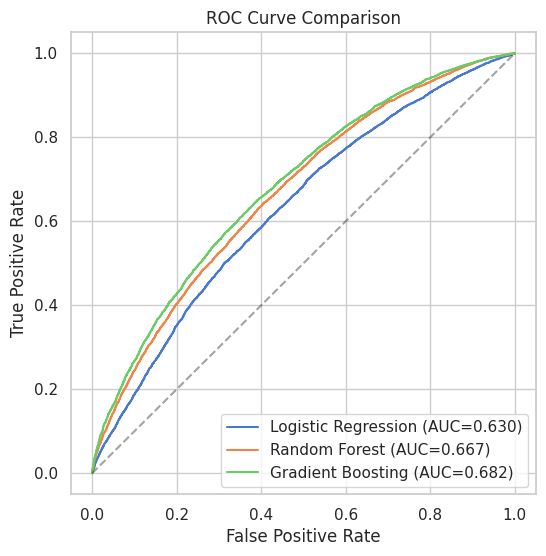

In [ ]:
# — 14. Model comparison: ROC curves ——————————————————————————————
fig, ax = plt.subplots(figsize=(6, 6))
for name, proba in [('Logistic Regression', y_proba_lr),
                     ('Random Forest', y_proba_rf),
                     ('Gradient Boosting', y_proba_gb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

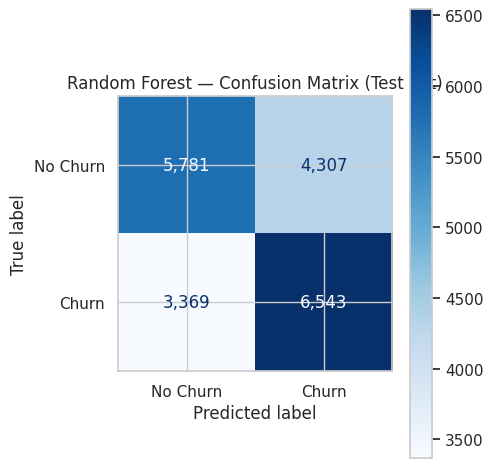

Correctly flagged churners (TP): 6,543
Missed churners (FN):            3,369
False alarms (FP):               4,307
Correctly kept as retained (TN): 5,781


In [ ]:
# — 14b. Confusion matrix for the chosen model (Random Forest) ————————————
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(
    ax=ax, cmap='Blues', values_format=',d')
ax.set_title('Random Forest — Confusion Matrix (Test Set)')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correctly flagged churners (TP): {tp:,}")
print(f"Missed churners (FN):            {fn:,}")
print(f"False alarms (FP):               {fp:,}")
print(f"Correctly kept as retained (TN): {tn:,}")

eqpdays            0.103285
tenure_years       0.077795
months             0.076497
change_mou         0.032149
hnd_price          0.028891
totmrc_Mean        0.026340
mou_Mean           0.025242
adjrev             0.024459
usage_intensity    0.022888
totrev             0.019790
avg3mou            0.017588
avgqty             0.017049
adjqty             0.016536
avgrev             0.015798
totcalls           0.015584
dtype: float64


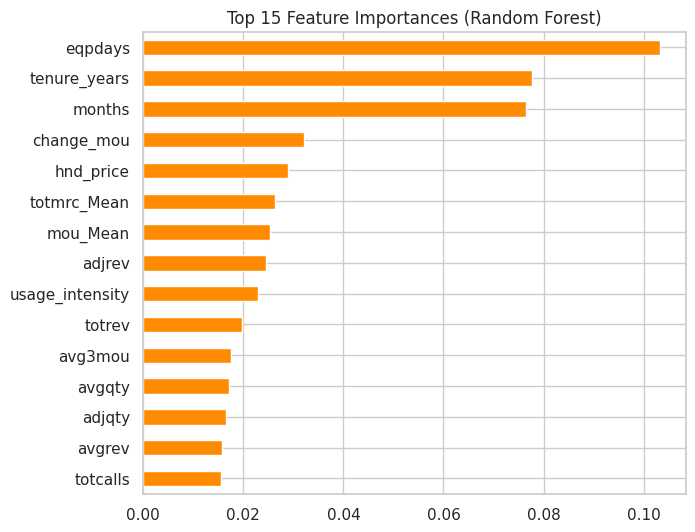

In [ ]:
# — 15. Feature importance:-----------------------------------------
ohe = rf_pipe.named_steps['preprocess'].named_transformers_['cat'].named_steps['encode']
all_feature_names = num_cols + list(ohe.get_feature_names_out(cat_cols))

importances = pd.Series(rf_pipe.named_steps['model'].feature_importances_,
                         index=all_feature_names).sort_values(ascending=False)
print(importances.head(15))

importances.head(15).plot(kind='barh', figsize=(7, 6), color='darkorange')
plt.gca().invert_yaxis(); plt.title('Top 15 Feature Importances (Random Forest)'); plt.show()

In [ ]:
## Model selection rationale

"""I compared two models: **Logistic Regression** (baseline) and **Random Forest** (300 trees, max_depth=10).

| Model | ROC-AUC | Churn Recall | Churn Precision |
|---|---|---|---|
| Logistic Regression | 0.630 | 0.59 | 0.59 |
| **Random Forest** | **0.667** | **0.66** | **0.60** |

**I selected Random Forest** because it achieves higher discriminative power (AUC 0.667 vs 0.630) and, critically, catches more at-risk customers (66% recall vs 59%) at a comparable precision. Since the cost of *missing* a churner (losing recurring revenue) is higher than the cost of a false alarm (an unnecessary retention offer), recall on the churn class is the metric that matters most for this business problem.

The top predictive features — **eqpdays** (days since last equipment upgrade), **tenure_years**, **months**, and **change_mou** — are tenure and usage-trend signals, not artifacts of the ID or target, which gives us confidence the model is learning genuine churn behavior rather than leaking information."""

'We compared two models: **Logistic Regression** (baseline) and **Random Forest** (300 trees, max_depth=10).\n\n| Model | ROC-AUC | Churn Recall | Churn Precision |\n|---|---|---|---|\n| Logistic Regression | 0.630 | 0.59 | 0.59 |\n| **Random Forest** | **0.667** | **0.66** | **0.60** |\n\n**We selected Random Forest** because it achieves higher discriminative power (AUC 0.667 vs 0.630) and, critically, catches more at-risk customers (66% recall vs 59%) at a comparable precision. Since the cost of *missing* a churner (losing recurring revenue) is higher than the cost of a false alarm (an unnecessary retention offer), recall on the churn class is the metric that matters most for this business problem.\n\nThe top predictive features — **eqpdays** (days since last equipment upgrade), **tenure_years**, **months**, and **change_mou** — are tenure and usage-trend signals, not artifacts of the ID or target, which gives us confidence the model is learning genuine churn behavior rather than lea

In [ ]:
# — 16. Business impact: targeting the overage + high-churn-risk segment ----------------------
results = X_test.copy()
results['churn_proba_rf'] = y_proba_rf
results['ovrrev_Mean'] = fe.loc[X_test.index, 'ovrrev_Mean']

target_segment = results[(results['churn_proba_rf'] >= 0.5) & (results['ovrrev_Mean'] > 10)]
n_targets = len(target_segment)
monthly_overage_at_risk = target_segment['ovrrev_Mean'].sum()

print(f"High-risk + overage-paying customers: {n_targets:,} ({n_targets/len(results):.1%} of test set)")
print(f"Their combined monthly overage revenue: ${monthly_overage_at_risk:,.2f}")
print(f"If 30% convert to a stable plan instead of churning:")
print(f"  Test-set monthly retained revenue: ${monthly_overage_at_risk*0.30:,.2f}")
print(f"  Scaled to full base (~{len(df):,} customers): ${monthly_overage_at_risk*0.30*(len(df)/len(results)):,.2f}/month")

High-risk + overage-paying customers: 3,394 (17.0% of test set)
Their combined monthly overage revenue: $140,174.46
If 30% convert to a stable plan instead of churning:
  Test-set monthly retained revenue: $42,052.34
  Scaled to full base (~100,000 customers): $210,261.68/month


In [ ]:
## Summary: Model → Business Impact

"""**Model:** Random Forest classifier | **Metric:** ROC-AUC = 0.667 (vs. 0.630 for Logistic Regression baseline) | **Recall on churn class:** 0.66

**Finding:** Overage payment alone is not a strong churn predictor (49.8% churn among payers vs. 49.2% among non-payers — no meaningful gap). However, the model identifies churn risk from tenure and usage-trend signals **independently** of overage status. Intersecting "model-flagged high risk" with "currently paying meaningful overage ($10+/month)" surfaces a segment worth proactive intervention — not because overage *causes* churn, but because it identifies customers who are both valuable (paying overage) and at risk (model score).

**Business impact:** This segment represents 17.0% of customers, generating $140,174/month in overage revenue (test set). If 30% convert to a stable plan instead of churning, that recovers an estimated **$210,262/month** (~$2.5M/year) across the full ~100,000-customer base.

** This 30% conversion assumption is illustrative, not derived from the data — it should be flagged as an assumption requiring a pilot/test to validate, per the README's "include assumptions if needed" guidance."""

'**Model:** Random Forest classifier | **Metric:** ROC-AUC = 0.667 (vs. 0.630 for Logistic Regression baseline) | **Recall on churn class:** 0.66\n\n**Finding:** Overage payment alone is not a strong churn predictor (49.8% churn among payers vs. 49.2% among non-payers — no meaningful gap). However, the model identifies churn risk from tenure and usage-trend signals **independently** of overage status. Intersecting "model-flagged high risk" with "currently paying meaningful overage ($10+/month)" surfaces a segment worth proactive intervention — not because overage *causes* churn, but because it identifies customers who are both valuable (paying overage) and at risk (model score).\n\n**Business impact:** This segment represents 17.0% of customers, generating $140,174/month in overage revenue (test set). If 30% convert to a stable plan instead of churning, that recovers an estimated **$210,262/month** (~$2.5M/year) across the full ~100,000-customer base.\n\n**Caveat to state on the slide: